# Test Gabor filter generation - temporally changing
In this workbook you can familiarize yourself with (temporally changing) Gabor filters, and their generation. You can play around with useful parameter ranges. 
## Raw, pixel-based Gabor filter generation 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from wavelet_utils_vSpeed import makeGaborFilter_vS

angle_deg=30
angle=np.deg2rad(angle_deg)
phase=0
drift=5 #pixels per frame
screen_x=70 #pixels
screen_y=50 
i=screen_x//2 #pixels
j=screen_y//2

size=20 #pixels
frequency=0.1 #cycles per pixel

screen=makeGaborFilter_vS(i, j, angle, size, frequency, drift, phase, screen_x=screen_x, screen_y=screen_y, screen_t=5)

Text(0.5, 0.98, 'angle=0.52, size=20.00, frequency=0.10, size=20.00, drift=5.00, phase=0.00\n max=0.0022068023681640625, min=-0.0018548965454101562')

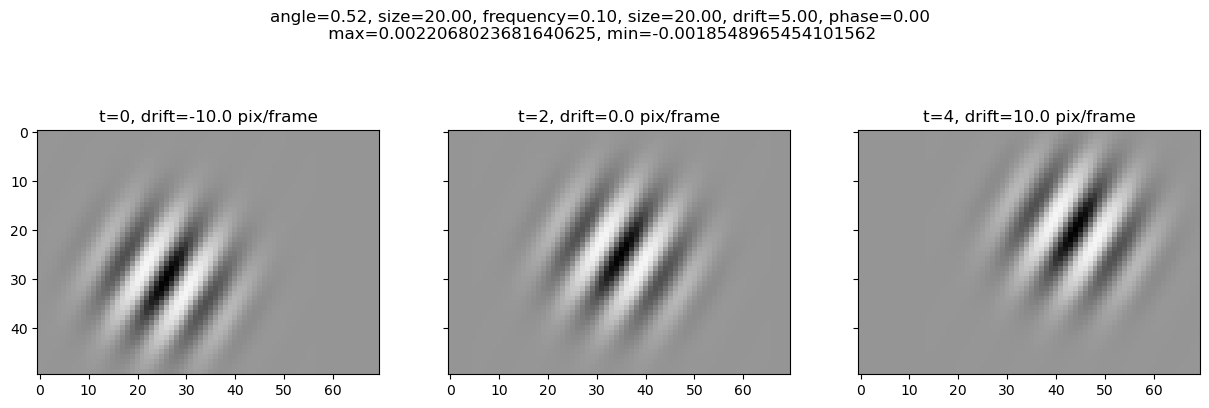

In [3]:
t0=screen.shape[0]//2
ts=[0, t0, screen.shape[0]-1]
v = np.max(np.abs(screen))
fig, ax = plt.subplots(1,3, figsize=(15, 5), sharex=True, sharey=True)
for t, axi in zip(ts, ax):
    axi.imshow(screen[t].T, cmap='Greys', vmin=-v, vmax=v)
    axi.set_title(f't={t}, drift={drift*(t-t0):.1f} pix/frame')

fig.suptitle(f'angle={angle:.2f}, size={size:.2f}, frequency={frequency:.2f}, size={size:.2f}, drift={drift:.2f}, phase={phase:.2f}\n max={np.max(screen)}, min={np.min(screen)}')

## Display usable range

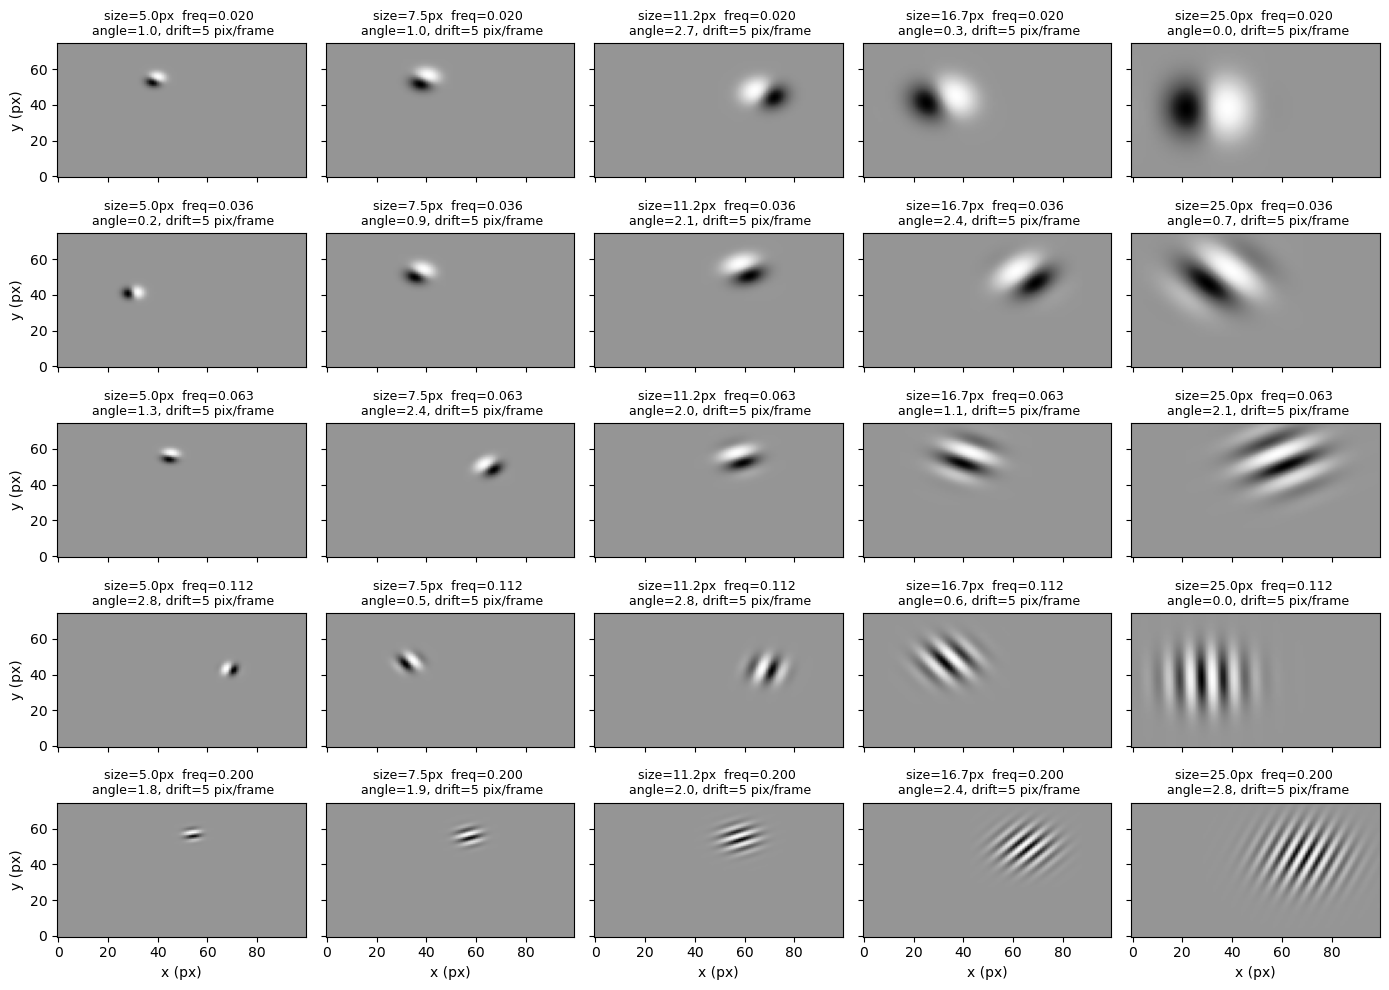

In [4]:

screen_x = 100
screen_y = 75

# center in pixels
i = screen_x // 2
j = screen_y // 2

sizes = np.logspace(np.log10(5), np.log10(25), 5)
freqs = np.logspace(np.log10(0.02), np.log10(0.2), 5)

phase = np.pi / 2

fig, axes = plt.subplots(len(freqs), len(sizes), figsize=(14, 10), sharex=True, sharey=True)

for row, frequency in enumerate(freqs):
    for col, size in enumerate(sizes):
        angle = np.random.uniform(0, np.pi)

        filt = makeGaborFilter_vS(
            i=i,
            j=j,
            angle=angle,
            size=size,
            frequency=frequency,
            drift=10,
            phase=phase,
            screen_x=screen_x,
            screen_y=screen_y,
            screen_t=5
        )

        ax = axes[row, col]
        v = np.max(np.abs(filt))

        t=0#filt.shape[0]//2
        ax.imshow(
            filt[t].T,
            cmap="Greys",
            vmin=-v,
            vmax=v,
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={size:.1f}px  freq={frequency:.3f} \n angle={angle:.1f}, drift={drift} pix/frame",
            fontsize=9
        )

        if row == len(freqs) - 1:
            ax.set_xlabel("x (px)")
        if col == 0:
            ax.set_ylabel("y (px)")

plt.tight_layout()
plt.show()

## Visual degree-based Gabor filter generation

In [5]:
from wavelet_utils_vSpeed import makeGaborFilter_visual_vS
import numpy as np

visual_coverage = [-88, 0, -33, 33]
angle_deg=30
angle=np.deg2rad(angle_deg)
phase=0

screen_x=100
screen_y=None
screen_t=3

i=-45
j=10

size=20 #degrees
freq2=.1
drift=5

screen=makeGaborFilter_visual_vS(i, j,  angle, size, freq2, drift, phase, visual_coverage, screen_x=screen_x, screen_y=screen_y, screen_t=screen_t)

Text(0.5, 0.98, 'angle=0.52, size=20.00, frequency=0.10, size=20.00, drift=5.00, phase=0.00\n max=0.001708984375, min=-0.00153350830078125')

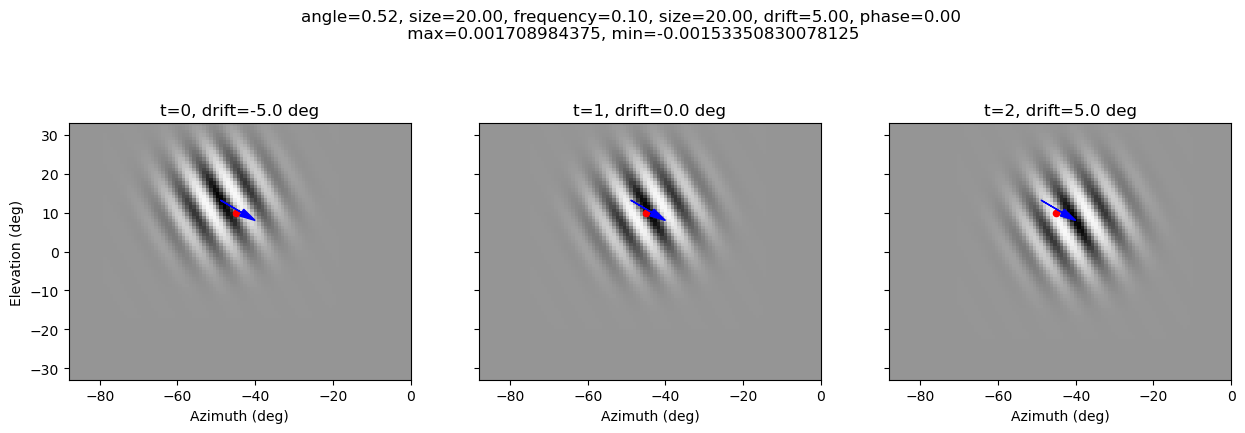

In [6]:
import matplotlib.pyplot as plt
from wavelet_utils_vSpeed import get_filter_vector

t0=screen.shape[0]//2
ts=[0, t0, screen.shape[0]-1]
v = np.max(np.abs(screen))
fig, ax = plt.subplots(1,3, figsize=(15, 5), sharex=True, sharey=True)
az_left, az_right, el_bottom, el_top = visual_coverage
x1, y1, dx, dy = get_filter_vector(screen, visual_coverage)
for t, axi in zip(ts, ax):
    axi.imshow(screen[t].T, cmap='Greys', vmin=-v, vmax=v, aspect='equal', origin='lower', extent=[az_left, az_right, el_bottom, el_top])
    axi.set_title(f't={t}, drift={drift*(t-t0):.1f} deg')
    axi.set_xlabel('Azimuth (deg)')
    axi.scatter(i, j, color='red', s=20)
    axi.arrow(x1, y1, dx, dy, color='blue', head_width=2, head_length=4, length_includes_head=True)

ax[0].set_ylabel('Elevation (deg)')
fig.suptitle(f'angle={angle:.2f}, size={size:.2f}, frequency={freq2:.2f}, size={size:.2f}, drift={drift:.2f}, phase={phase:.2f}\n max={np.max(screen)}, min={np.min(screen)}')


## Display usable range

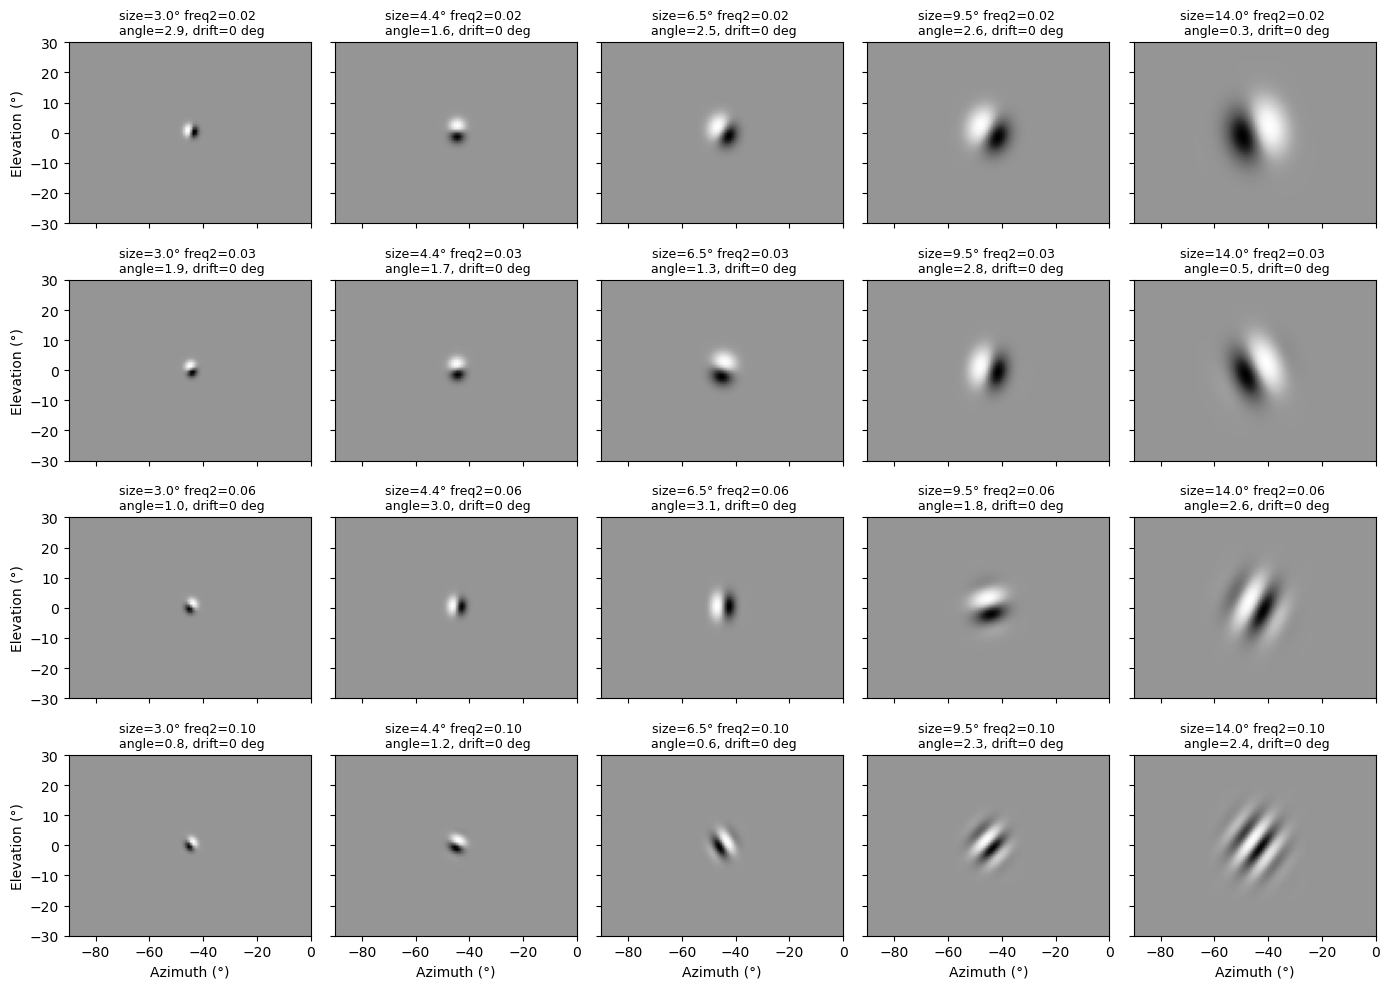

In [7]:
import numpy as np
import matplotlib.pyplot as plt

visual_coverage = [-90, 0, -30, 30]
screen_x = 100
screen_y = None
screen_t = 5

az_left, az_right, el_bottom, el_top = visual_coverage

# center in visual degrees
i_deg = (az_left + az_right) / 2
j_deg = (el_bottom + el_top) / 2

sizes = np.logspace(np.log10(3), np.log10(14), 5)
freq2s = np.logspace(np.log10(.02), np.log10(.1), 4)

phase = np.pi / 2
#phase = 0

drift = 0

fig, axes = plt.subplots(len(freq2s), len(sizes), figsize=(14, 10), sharex=True, sharey=True)

for row, freq2 in enumerate(freq2s):
    for col, size_deg in enumerate(sizes):
        angle = np.random.uniform(0, np.pi)

        filt = makeGaborFilter_visual_vS(
            i_deg=i_deg,
            j_deg=j_deg,
            angle=angle,
            size_deg=size_deg,
            freq_deg=freq2,
            drift_deg=drift,
            phase=phase,
            visual_coverage=visual_coverage,
            screen_x=screen_x,
            screen_y=screen_y,
            screen_t=screen_t
        )

        ax = axes[row, col]

        v = np.max(np.abs(filt))

        ax.imshow(
            filt[0 ].T,  
            cmap="Greys",
            vmin=-v,
            vmax=v,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={size_deg:.1f}° freq2={freq2:.2f} \n angle={angle:.1f}, drift={drift} deg",
            fontsize=9
        )

        if row == len(freq2s) - 1:
            ax.set_xlabel("Azimuth (°)")
        if col == 0:
            ax.set_ylabel("Elevation (°)")

plt.tight_layout()
plt.show()